In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px

In [2]:
df_w = pd.read_parquet("../data/processed/master_deliveries.parquet")
df_w.head()

,match_id,date,venue,stage,innings_no,batting_team,bowling_team,over,ball,batter,...,byes,legbyes,team_ball_faced,is_four,is_six,is_boundary,is_wicket,player_out,wicket_kind,fielder
0,1150533,2018-11-09,Providence Stadium,Group Stage,1,India,New Zealand,0,1,T Bhatia,...,0,0,1,1,0,1,0,None,None,None
1,1150533,2018-11-09,Providence Stadium,Group Stage,1,India,New Zealand,0,2,T Bhatia,...,0,0,1,0,0,0,0,None,None,None
2,1150533,2018-11-09,Providence Stadium,Group Stage,1,India,New Zealand,0,3,T Bhatia,...,0,0,1,1,0,1,0,None,None,None
3,1150533,2018-11-09,Providence Stadium,Group Stage,1,India,New Zealand,0,4,T Bhatia,...,0,0,1,0,0,0,0,None,None,None
4,1150533,2018-11-09,Providence Stadium,Group Stage,1,India,New Zealand,0,5,T Bhatia,...,0,0,1,0,0,0,0,None,None,None


In [3]:
df_w.tail()

,match_id,date,venue,stage,innings_no,batting_team,bowling_team,over,ball,batter,...,byes,legbyes,team_ball_faced,is_four,is_six,is_boundary,is_wicket,player_out,wicket_kind,fielder
39306,951419,2016-04-03,Eden Gardens,Final,2,West Indies,Australia,18,5,B Cooper,...,0,0,1,0,0,0,0,None,None,None
39307,951419,2016-04-03,Eden Gardens,Final,2,West Indies,Australia,18,6,DJS Dottin,...,0,0,1,0,0,0,0,None,None,None
39308,951419,2016-04-03,Eden Gardens,Final,2,West Indies,Australia,19,1,DJS Dottin,...,0,0,1,0,0,0,0,None,None,None
39309,951419,2016-04-03,Eden Gardens,Final,2,West Indies,Australia,19,2,B Cooper,...,0,0,1,0,0,0,0,None,None,None
39310,951419,2016-04-03,Eden Gardens,Final,2,West Indies,Australia,19,3,B Cooper,...,0,0,1,0,0,0,0,None,None,None


In [4]:
df_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39311 entries, 0 to 39310
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   match_id         39311 non-null  object
 1   date             39311 non-null  object
 2   venue            39311 non-null  object
 3   stage            39311 non-null  object
 4   innings_no       39311 non-null  int64 
 5   batting_team     39311 non-null  object
 6   bowling_team     39311 non-null  object
 7   over             39311 non-null  int64 
 8   ball             39311 non-null  int64 
 9   batter           39311 non-null  object
 10  bowler           39311 non-null  object
 11  non_striker      39311 non-null  object
 12  batter_runs      39311 non-null  int64 
 13  extra_runs       39311 non-null  int64 
 14  total_runs       39311 non-null  int64 
 15  wides            39311 non-null  int64 
 16  noballs          39311 non-null  int64 
 17  byes             39311 non-null

In [5]:
df_w.describe

<bound method NDFrame.describe of       match_id        date               venue        stage  innings_no  \
0      1150533  2018-11-09  Providence Stadium  Group Stage           1   
1      1150533  2018-11-09  Providence Stadium  Group Stage           1   
2      1150533  2018-11-09  Providence Stadium  Group Stage           1   
3      1150533  2018-11-09  Providence Stadium  Group Stage           1   
4      1150533  2018-11-09  Providence Stadium  Group Stage           1   
...        ...         ...                 ...          ...         ...   
39306   951419  2016-04-03        Eden Gardens        Final           2   
39307   951419  2016-04-03        Eden Gardens        Final           2   
39308   951419  2016-04-03        Eden Gardens        Final           2   
39309   951419  2016-04-03        Eden Gardens        Final           2   
39310   951419  2016-04-03        Eden Gardens        Final           2   

      batting_team bowling_team  over  ball      batter  ... byes

In [6]:
df_w['year'] = df_w['date'].astype(str).str.slice(0, 4)
year_data_dict = {
    year: group for year, group in df_w.groupby('year')
}
print(year_data_dict)
print(f"Data successfully split across {len(year_data_dict)} individual years.")

{'2014':       match_id        date           venue               stage  innings_no  \
28401   682967  2014-03-23  Sylhet Stadium         Group Stage           1   
28402   682967  2014-03-23  Sylhet Stadium         Group Stage           1   
28403   682967  2014-03-23  Sylhet Stadium         Group Stage           1   
28404   682967  2014-03-23  Sylhet Stadium         Group Stage           1   
28405   682967  2014-03-23  Sylhet Stadium         Group Stage           1   
...        ...         ...             ...                 ...         ...   
33858   718467  2014-04-03  Sylhet Stadium  9th Place Play-Off           2   
33859   718467  2014-04-03  Sylhet Stadium  9th Place Play-Off           2   
33860   718467  2014-04-03  Sylhet Stadium  9th Place Play-Off           2   
33861   718467  2014-04-03  Sylhet Stadium  9th Place Play-Off           2   
33862   718467  2014-04-03  Sylhet Stadium  9th Place Play-Off           2   

      batting_team bowling_team  over  ball       batt

In [7]:
def generate_match_summaries(dataframe):
    if 'year' not in dataframe.columns:
        dataframe['year'] = pd.to_datetime(dataframe['date']).dt.year
        
    base_summary = dataframe.groupby(['year', 'match_id', 'venue', 'stage', 'innings_no', 'batting_team']).agg(
        runs=('total_runs', 'sum'),
        balls=('team_ball_faced', 'sum'),
        extras=('extra_runs', 'sum'),
        wickets=('is_wicket', 'sum'),
        boundaries=('is_boundary', 'sum')
    ).reset_index()

    pivot_df = base_summary.pivot(
        index=['year', 'match_id', 'venue', 'stage'], 
        columns='innings_no', 
        values=['batting_team', 'runs', 'balls', 'extras', 'wickets', 'boundaries']
    )
    
    pivot_df.columns = [f"{col[0]}_inn{col[1]}" for col in pivot_df.columns]
    match_summary = pivot_df.reset_index()
    
    
    if 'batting_team_inn2' not in match_summary.columns:
        match_summary['batting_team_inn2'] = 'No Second Innings'
    else:
        match_summary['batting_team_inn2'] = match_summary['batting_team_inn2'].fillna('No Second Innings')
        
    for data_metric in ['runs_inn2', 'balls_inn2', 'extras_inn2', 'wickets_inn2', 'boundaries_inn2']:
        if data_metric in match_summary.columns:
            match_summary[data_metric] = match_summary[data_metric].fillna(0)
        else:
            match_summary[data_metric] = 0

    
    match_summary = match_summary.rename(columns={
        'batting_team_inn1': 'team_1',
        'batting_team_inn2': 'team_2',
        
        'runs_inn1': 'team1_runs',
        'balls_inn1': 'team1_balls_faced',
        'extras_inn1': 'team1_extras_conceded',
        'wickets_inn1': 'team1_wickets_lost',
        'boundaries_inn1': 'team1_boundaries',
        
        'runs_inn2': 'team2_runs',
        'balls_inn2': 'team2_balls_faced',
        'extras_inn2': 'team2_extras_conceded',
        'wickets_inn2': 'team2_wickets_lost',
        'boundaries_inn2': 'team2_boundaries'
    })

    def calculate_winner(row):
        if row['team_2'] == 'No Second Innings':
            return pd.Series(['Abandoned', 'N/A'])
        if row['team1_runs'] > row['team2_runs']:
            return pd.Series([row['team_1'], f"{int(row['team1_runs'] - row['team2_runs'])} runs"])
        elif row['team2_runs'] > row['team1_runs']:
            return pd.Series([row['team_2'], f"{int(10 - row['team2_wickets_lost'])} wickets"])
    
        return pd.Series(['Tie', 'N/A'])

    match_summary[['winner', 'margin']] = match_summary.apply(calculate_winner, axis=1)
    return match_summary

all_match_summaries = generate_match_summaries(df_w)
all_match_summaries.head(5)

,year,match_id,venue,stage,team_1,team_2,team1_runs,team2_runs,team1_balls_faced,team2_balls_faced,team1_extras_conceded,team2_extras_conceded,team1_wickets_lost,team2_wickets_lost,team1_boundaries,team2_boundaries,winner,margin
0,2014,682967,Sylhet Stadium,Group Stage,New Zealand,Australia,128,121,120,117,2,4,8,10,17,11,New Zealand,7 runs
1,2014,682971,Sylhet Stadium,Group Stage,West Indies,England,133,124,120,120,6,10,7,9,14,15,West Indies,9 runs
2,2014,682973,Sylhet Stadium,Group Stage,Sri Lanka,India,128,106,120,120,8,3,8,9,14,9,Sri Lanka,22 runs
3,2014,682975,Sylhet Stadium,Group Stage,New Zealand,Ireland,171,129,122,120,10,6,3,6,21,17,New Zealand,42 runs
4,2014,682979,Sylhet Stadium,Group Stage,West Indies,Bangladesh,115,79,120,105,7,3,10,10,13,8,West Indies,36 runs


In [8]:
for year, data_subset in year_data_dict.items():
    summary = generate_match_summaries(data_subset)
    output_filename = f"../data/processed/match_summaries/match_summary_{year}.csv"
    summary.to_csv(output_filename, index = False)

In [9]:
def generate_batting_scoresheet(dataframe):
    balls_faced_batting = dataframe[dataframe['wides'] == 0]
    
    balls_faced_batting['is_four'] = (balls_faced_batting['batter_runs'] == 4).astype(int)
    balls_faced_batting['is_six'] = (balls_faced_batting['batter_runs'] == 6).astype(int)
    balls_faced_batting['is_dot'] = (balls_faced_batting['batter_runs'] == 0).astype(int)
    
    batting_stats = balls_faced_batting.groupby([
        'year',
        'match_id',
        'stage',
        'innings_no',
        'batting_team',
        'batter']).agg(
        runs_scored = ('batter_runs', 'sum'),
        balls_faced = ('batter_runs', 'count'),
        sixes = ('is_six', 'sum'),
        fours = ('is_four', 'sum'),
        dot_balls = ('is_dot', 'sum')
    ).reset_index()
    
    batting_stats['strike_rate'] = ((batting_stats['runs_scored'] / batting_stats['balls_faced']) * 100).round(2)
    batting_stats['dot_ball_percentage'] = ((batting_stats['dot_balls']/ batting_stats['balls_faced']) * 100).round(2)
    
    dismissals = dataframe[dataframe['player_out'].notna()]
    
    dismissals = dismissals[[
        'match_id',
        'innings_no',
        'player_out',
        'wicket_kind',
        'bowler'
        ]].rename(
            columns = {
                'player_out': 'batter'
            }
        )
    
    final_scorecard = batting_stats.merge(dismissals, on =[
        'match_id', 'innings_no', 'batter'
    ], how = 'left')
        
    final_scorecard['wicket_kind'] = final_scorecard['wicket_kind'].fillna('not out')
    final_scorecard['bowler'] = final_scorecard['bowler'].fillna('')
    
    final_scorecard_sorted = final_scorecard.sort_values(
        by = ['match_id', 'innings_no', 'runs_scored'],
        ascending = [True, True, False]
    )
    
    final_scorecard_sorted = final_scorecard_sorted.drop(columns = ['dot_balls'])
    
    
    return final_scorecard_sorted

df_batting_scorecards = generate_batting_scoresheet(df_w)
df_batting_scorecards.head(5)

C:\Users\aryam\AppData\Local\Temp\ipykernel_21700\2488796477.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  balls_faced_batting['is_four'] = (balls_faced_batting['batter_runs'] == 4).astype(int)
C:\Users\aryam\AppData\Local\Temp\ipykernel_21700\2488796477.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  balls_faced_batting['is_six'] = (balls_faced_batting['batter_runs'] == 6).astype(int)
C:\Users\aryam\AppData\Local\Temp\ipykernel_21700\2488796477.py:6: SettingWithCopyWarning: 
A value is trying to 

,year,match_id,stage,innings_no,batting_team,batter,runs_scored,balls_faced,sixes,fours,strike_rate,dot_ball_percentage,wicket_kind,bowler
732,2018,1150533,Group Stage,1,India,H Kaur,103,51,8,7,201.96,29.41,caught,SFM Devine
733,2018,1150533,Group Stage,1,India,JI Rodrigues,59,45,0,7,131.11,26.67,stumped,JM Watkin
731,2018,1150533,Group Stage,1,India,D Hemalatha,15,7,0,2,214.29,14.29,caught,LM Kasperek
736,2018,1150533,Group Stage,1,India,T Bhatia,9,6,0,2,150.00,50.00,bowled,LMM Tahuhu
735,2018,1150533,Group Stage,1,India,S Mandhana,2,7,0,0,28.57,85.71,caught,LMM Tahuhu


In [10]:
def generate_bowling_figures(dataframe):
    dataframe['bowler_runs'] = dataframe['batter_runs'] + dataframe['wides'] + dataframe['noballs']
    dataframe['is_legal_ball'] = (dataframe['wides'] == 0) & (dataframe['noballs'] == 0)
    
    bowler_wicket_kinds = [
        'bowled',
        'caught',
        'caught and bowled',
        'lbw',
        'stumped']
    dataframe['is_bowler_wicket'] = dataframe['wicket_kind'].isin(bowler_wicket_kinds).astype(int)
    dataframe['is_dot_ball'] = ((dataframe['bowler_runs'] == 0) & dataframe['is_legal_ball']).astype(int)
    dataframe['is_four_conceded'] = (dataframe['batter_runs'] == 4).astype(int)
    dataframe['is_six_conceded'] = (dataframe['batter_runs'] == 6).astype(int)
    
    bowling_stats = dataframe.groupby([
        'year',
        'match_id',
        'stage',
        'innings_no',
        'bowling_team',
        'bowler'
    ]).agg(
        runs_conceded = ('bowler_runs', 'sum'),
        legal_balls_bowled = ('is_legal_ball', 'sum'),
        wickets_taken = ('is_bowler_wicket', 'sum'),
        dots_bowled = ('is_dot_ball', 'sum'),
        fours_conceded = ('is_four_conceded', 'sum'),
        sixes_conceded = ('is_six_conceded', 'sum')
    ).reset_index()
    
    bowling_stats['overs'] = (bowling_stats['legal_balls_bowled'] // 6) + ((bowling_stats['legal_balls_bowled'] % 6) / 10)
    
    bowling_stats['economy'] = np.where(
        bowling_stats['legal_balls_bowled'] > 0,
        ((bowling_stats['runs_conceded'] / bowling_stats['legal_balls_bowled']) * 6).round(2),
        bowling_stats['runs_conceded'].astype(float)
    )
    
    bowling_stats['bowling_average'] = np.where(
        bowling_stats['wickets_taken'] > 0,
        (bowling_stats['runs_conceded'] / bowling_stats['wickets_taken']).round(2),
        np.nan
    )
    
    bowling_stats['bowling_strike_rate'] = np.where(
        bowling_stats['wickets_taken'] > 0,
        (bowling_stats['legal_balls_bowled'] / bowling_stats['wickets_taken']).round(2),
        np.nan
    )
    
    bowling_stats['dot_ball_percentage'] = np.where(
        bowling_stats['legal_balls_bowled'] > 0,
        ((bowling_stats['dots_bowled'] / bowling_stats['legal_balls_bowled']) * 100).round(2),
        0.0
    )
    
    return bowling_stats.sort_values(
        by = ['match_id', 'innings_no', 'wickets_taken','economy'],
        ascending = [True, True, False, True]
        ).reset_index(drop = True)
    
df_bowling_figures = generate_bowling_figures(df_w) 
df_bowling_figures.head(5)

,year,match_id,stage,innings_no,bowling_team,bowler,runs_conceded,legal_balls_bowled,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,overs,economy,bowling_average,bowling_strike_rate,dot_ball_percentage
0,2018,1150533,Group Stage,1,New Zealand,LMM Tahuhu,18,18,2,11,3,0,3.0,6.00,9.0,9.0,61.11
1,2018,1150533,Group Stage,1,New Zealand,LM Kasperek,28,24,1,9,1,1,4.0,7.00,28.0,24.0,37.50
2,2018,1150533,Group Stage,1,New Zealand,SFM Devine,22,18,1,5,2,0,3.0,7.33,22.0,18.0,27.78
3,2018,1150533,Group Stage,1,New Zealand,JM Watkin,40,18,1,6,2,4,3.0,13.33,40.0,18.0,33.33
4,2018,1150533,Group Stage,1,New Zealand,AC Kerr,36,24,0,6,4,1,4.0,9.00,NaN,NaN,25.00


In [11]:
batter_total_year = df_batting_scorecards.groupby([
    'year',
    'batter'
])['runs_scored'].sum().reset_index()

batter_total_year_sorted = batter_total_year.sort_values(by = [
    'year', 
    'runs_scored'
], ascending = [True, False])

df_highest_run_getter_year = batter_total_year_sorted.groupby('year').head(5).reset_index(drop = True)

df_highest_run_getter_year['rank'] = df_highest_run_getter_year.groupby('year').cumcount() + 1
df_highest_run_getter_year['display'] = df_highest_run_getter_year['batter'] + "(" + df_highest_run_getter_year['runs_scored'].astype(str) + ")"

pivot_output = df_highest_run_getter_year.pivot(
    index = 'rank',
    columns = 'year',
    values = 'display'
    )

pivot_output.index.name = 'Position'
print(pivot_output)

year                 2014             2016               2018  \
Position                                                        
1           SW Bates(228)   SR Taylor(246)      AJ Healy(225)   
2              M Raj(208)  CM Edwards(202)        H Kaur(183)   
3          SR Taylor(153)  MM Lanning(201)    S Mandhana(178)   
4         DJS Dottin(147)    SW Bates(183)      SW Bates(161)   
5         BYA Mendis(143)  EJ Villani(171)  Javeria Khan(136)   

year                    2020                  2023              2024  \
Position                                                               
1             BL Mooney(259)      L Wolvaardt(230)  L Wolvaardt(223)   
2              AJ Healy(236)  NR Sciver-Brunt(216)      T Brits(187)   
3             NR Sciver(202)        BL Mooney(206)     DN Wyatt(151)   
4             HC Knight(193)         AJ Healy(189)   GE Plimmer(150)   
5         Shafali Verma(163)          T Brits(186)       H Kaur(150)   

year                      2026  
Positi

In [12]:
fig = px.bar(
    df_highest_run_getter_year,
    x = 'runs_scored',
    y = 'batter',
    color = 'year',
    facet_col = 'year',
    facet_col_wrap = 2,
    orientation = 'h',
    title = "Top 5 Run Getters Year by Year",
    labels = {
        'runs_scored': 'Total Runs', 'batter': 'Batter'
    },
    text = 'runs_scored'
)

fig.update_layout(showlegend = False, height = 600)
fig.update_yaxes(
    matches = None,
    categoryorder = 'total ascending',
    showticklabels = True)
fig.show()

In [13]:
bowler_total_year = df_bowling_figures.groupby([
    'year',
    'bowler'
])['wickets_taken'].sum().reset_index()

bowler_total_year_sorted = bowler_total_year.sort_values(by = [
    'year', 
    'wickets_taken'
], ascending = [True, False])

df_highest_wicket_taker_year = bowler_total_year_sorted.groupby('year').head(5).reset_index(drop = True)

df_highest_wicket_taker_year['rank'] = df_highest_wicket_taker_year.groupby('year').cumcount() + 1
df_highest_wicket_taker_year['display'] = df_highest_wicket_taker_year['bowler'] + "(" + df_highest_wicket_taker_year['wickets_taken'].astype(str) + ")"

pivot_output = df_highest_wicket_taker_year.pivot(
    index = 'rank',
    columns = 'year',
    values = 'display'
    )

pivot_output.index.name = 'Position'
print(pivot_output)

year                     2014            2016            2018  \
Position                                                        
1             A Shrubsole(11)   DJS Dottin(9)   A Gardner(10)   
2                 SJ Coyte(9)  LM Kasperek(9)  DJS Dottin(10)   
3             Poonam Yadav(8)   SFM Devine(9)   ML Schutt(10)   
4            Asmavia Iqbal(7)    SR Taylor(8)     EA Perry(9)   
5         HASD Siriwardene(7)  A Shrubsole(7)    KL Gordon(8)   

year                  2020              2023              2024  \
Position                                                         
1            ML Schutt(13)  S Ecclestone(11)       AC Kerr(15)   
2          JL Jonassen(10)     A Gardner(10)       N Mlaba(12)   
3         Poonam Yadav(10)     ML Schutt(10)  ASS Fletcher(10)   
4           A Shrubsole(8)         M Kapp(9)       RA Mair(10)   
5          S Ecclestone(8)     LMM Tahuhu(8)   A Sutherland(9)   

year                     2026  
Position                       
1         N Shree

In [14]:
fig = px.bar(
    df_highest_wicket_taker_year,
    x = 'wickets_taken',
    y = 'bowler',
    color = 'year',
    facet_col = 'year',
    facet_col_wrap = 2,
    orientation = 'h',
    title = "Top 5 Wicket Takers Year by Year",
    labels = {
        'wickets_taken': 'Wickets', 'bowler': 'Bowler'
    },
    text = 'wickets_taken'
)

fig.update_layout(showlegend = False, height = 600)
fig.update_yaxes(
    matches = None,
    categoryorder = 'total ascending',
    showticklabels = True)
fig.show()

In [15]:
# Batting and Bowling Evolution over the years

tournament_batting = df_batting_scorecards.groupby('year').agg(
    avg_sr = ('strike_rate', 'mean')
).reset_index()

tournament_bowling = df_bowling_figures.groupby('year').agg(
    avg_economy = ('economy', 'mean')
).reset_index()


yearly_trend_df = pd.merge(tournament_batting, tournament_bowling, on = 'year')

yearly_trend_df['Strike Rate New'] = ((yearly_trend_df['avg_sr']/yearly_trend_df['avg_sr'].iloc[0]) -1) * 100
yearly_trend_df['Bowling Economy New'] = ((yearly_trend_df['avg_economy']/yearly_trend_df['avg_economy'].iloc[0]) -1) * 100

In [16]:
df_plot = yearly_trend_df.copy()
if df_plot.index.name is not None:
    df_plot = df_plot.reset_index()
else:
    df_plot = df_plot.reset_index(drop=True)

# manual column name assignment to avoid duplication
new_cols = []
for i, col in enumerate(df_plot.columns):
    col_str = str(col).lower()
    if 'year' in col_str:
        new_cols.append('year')
    elif 'strike' in col_str or 'avg_sr' in col_str:
        new_cols.append('Strike_Rate_Change')
    elif 'economy' in col_str or 'avg_econ' in col_str:
        new_cols.append('Economy_Rate_Change')
    else:
        new_cols.append(f"unknown_col_{i}")

df_plot.columns = new_cols


# to remove duplicate columns
df_plot = df_plot.loc[:, ~df_plot.columns.duplicated()].copy()

fig_year_trends = px.line(
    df_plot,
    x='year',
    y=['Strike_Rate_Change', 'Economy_Rate_Change'],
    markers=True,
    title='Evolution of Play-Style',
    labels={
        'year': 'Tournament Year',
        'value': 'Change from 2014',
        'variable': 'Metric'
    }
)

fig_year_trends.update_layout(
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1)
)
fig_year_trends.show()

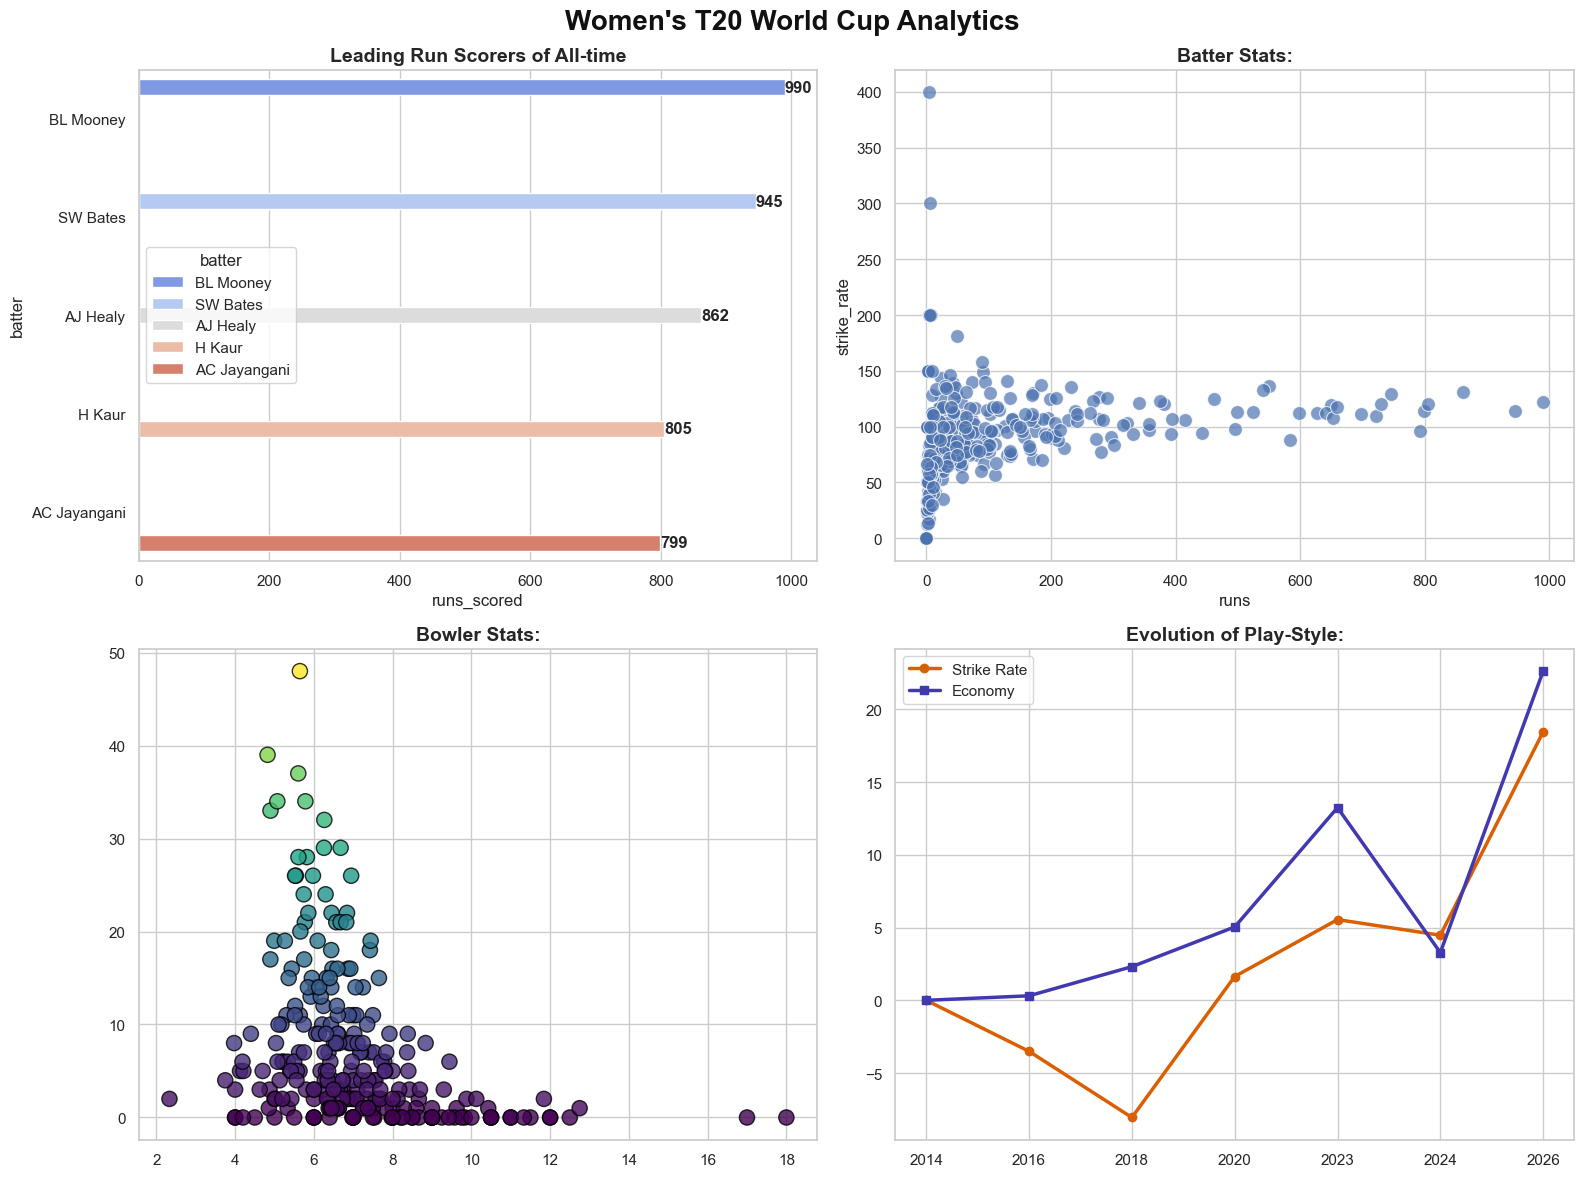

In [ ]:
tournament_batting = df_batting_scorecards.groupby('year').agg(
    avg_sr = ('strike_rate', 'mean')
).reset_index()

tournament_bowling = df_bowling_figures.groupby('year').agg(
    avg_economy = ('economy', 'mean')
).reset_index()


yearly_trend_df = pd.merge(tournament_batting, tournament_bowling, on = 'year')

yearly_trend_df['Strike Rate New'] = ((yearly_trend_df['avg_sr']/yearly_trend_df['avg_sr'].iloc[0]) -1) * 100
yearly_trend_df['Bowling Economy New'] = ((yearly_trend_df['avg_economy']/yearly_trend_df['avg_economy'].iloc[0]) -1) * 100

def build_dashboard(df_batting_scorecards, df_bowling_figures, yearly_trend_df):
    sns.set_theme(style = "whitegrid")
    
    fig, axes = plt.subplots(2 , 2, figsize = (16, 12))
    fig.suptitle("Women's T20 World Cup Analytics",
                 fontsize = 20,
                 fontweight = 'bold',
                 color = '#111111')
    
    # Top Run Scorers of All-time
    ax1 = axes[0, 0]
    top_batters = df_batting_scorecards.groupby('batter')['runs_scored'].sum().nlargest(5).reset_index()
    sns.barplot(
        x = 'runs_scored',
        y = 'batter',
        data = top_batters, 
        palette = 'coolwarm',
        ax = ax1,
        hue = 'batter'
    )
    ax1.set_title(
        "Leading Run Scorers of All-time",
        fontsize = 14,
        fontweight = 'bold'
    )
    for container in ax1.containers:
        ax1.bar_label(
            container,
            fmt = '%d',
            fontweight = 'bold'
    )
    
    # Batter => Strike Rate vs Runs Scored
    ax2 = axes[0, 1]
    player = df_batting_scorecards.groupby('batter').agg(
        runs = ('runs_scored', 'sum'),
        balls = ('balls_faced', 'sum')).reset_index()
    player['strike_rate'] = (player['runs'] / player['balls'] * 100)
    
    sns.scatterplot(
        x = 'runs', 
        y = 'strike_rate', 
        data = player,
        alpha = 0.7,
        s = 100, 
        ax = ax2
    )
    ax2.set_title(
        "Batter Stats:", 
        fontsize = 14, 
        fontweight = 'bold'
    )
    
    
    # Bowler => Wickets vs Economy
    ax3 = axes[1, 0]
    bowler_p = df_bowling_figures.groupby('bowler').agg(
            wickets = ('wickets_taken', 'sum'),
            runs_conceded = ('runs_conceded', 'sum'),
            balls = ('legal_balls_bowled', 'sum')).reset_index()
    bowler_p['economy'] = (bowler_p['runs_conceded'] / bowler_p['balls'] * 6)
    
    ax3.scatter(
        bowler_p['economy'],
        bowler_p['wickets'],
        c = bowler_p['wickets'], 
        cmap = 'viridis',
        s = 120, 
        edgecolors = 'black',
        alpha = 0.8
    )
    
    ax3.set_title(
        "Bowler Stats:",
        fontsize = 14, 
        fontweight = 'bold'
    )
    
    ax4 = axes[1, 1]
    
    ax4.plot(
        yearly_trend_df['year'].astype(str),
        yearly_trend_df['Strike Rate New'],
        marker='o',
        color='#d95f02',
        linewidth=2.5,
        label='Strike Rate'
    )
    
    ax4.plot(
        yearly_trend_df['year'].astype(str),
        yearly_trend_df['Bowling Economy New'],
        marker='s',
        color="#4139b0",
        linewidth=2.5,
        label='Economy'
    )
    
    ax4.set_title(
        'Evolution of Play-Style:',
        fontsize=14,
        fontweight='bold'
    )
    ax4.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show

build_dashboard(df_batting_scorecards,df_bowling_figures,yearly_trend_df)

In [18]:
df_w['match_phase'] = pd.cut(
    df_w['over'],
    bins = [-1, 5.6, 14.6, 20],
    labels = ["Powerplay", "Middle Overs", "Death Overs"]
)

df_w['is_legal_ball'] = ((df_w['wides'] == 0) & (df_w['noballs'] == 0)).astype(int)

team_phase_summary = df_w.groupby([
    'batting_team',
    'match_phase'
], observed = False).agg(
    total_runs_T = ('total_runs', 'sum'),
    legal_balls = ('is_legal_ball', 'sum') 
).reset_index()

team_phase_summary['run_rate'] = np.where(
    team_phase_summary['legal_balls'] > 0,
    ((team_phase_summary['total_runs_T'] / team_phase_summary['legal_balls']) * 6).round(2),
    0.0
)

min_balls_threshold = 120
teams_to_consider = team_phase_summary.groupby('batting_team')['legal_balls'].sum()
teams_to_consider = teams_to_consider[teams_to_consider >= min_balls_threshold].index

final_team_summary = team_phase_summary[team_phase_summary['batting_team'].isin(teams_to_consider)]

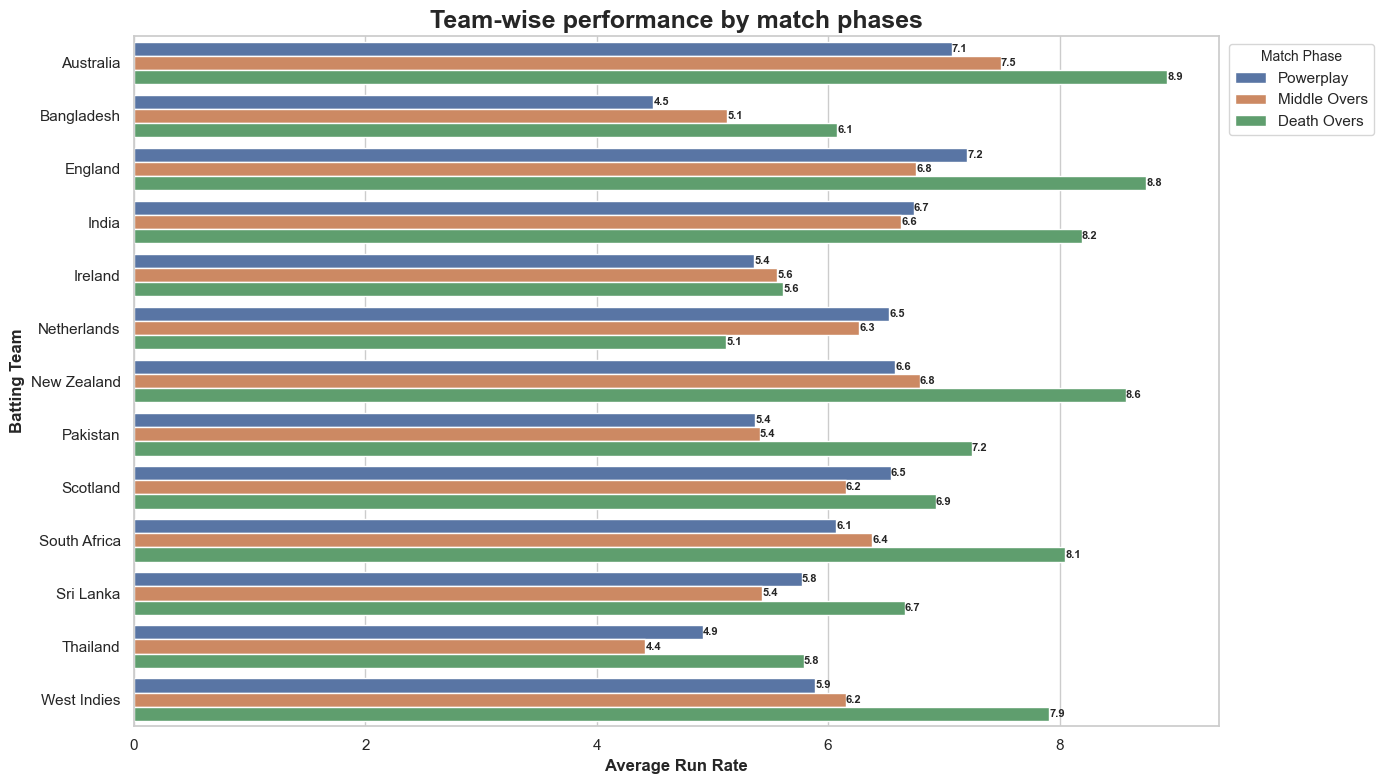

In [48]:
def team_phase_eff(dataframe):
    sns.set_theme(style = "whitegrid")
    
    fig, ax = plt.subplots(figsize = (14, 8))
    
    sns.barplot(
        data = dataframe,
        x = 'run_rate',
        y = 'batting_team',
        hue = 'match_phase',
        ax = ax
    )
    
    ax.set_title(
        "Team-wise performance by match phases",
        fontsize = 18,
        fontweight = 'bold'
    )
    
    ax.set_xlabel(
        "Average Run Rate",
        fontsize = 12,
        fontweight = 'bold'
    )
    
    ax.set_ylabel(
        "Batting Team",
        fontsize = 12,
        fontweight = 'bold'
    )
    
    ax.legend(
        title = "Match Phase",
        title_fontsize = '10',
        loc = 'upper right',
        bbox_to_anchor = (1.15, 1)
    )
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt = '%.1f',
            fontsize = 8, 
            fontweight = 'bold'
        )
        
    plt.tight_layout()
    plt.show()

team_phase_eff(final_team_summary)

In [20]:
df_w['match_phase'] = pd.cut(
    df_w['over'],
    bins = [-1, 5.6, 14.6, 20],
    labels = ["Powerplay", "Middle Overs", "Death Overs"]
)

df_w['is_boundary'] = df_w['batter_runs'].isin([4, 6]).astype(int)
df_w['is_dot_ball'] = ((df_w['total_runs'] == 0) & (df_w['wides'] == 0) & (df_w['noballs'] == 0)).astype(int)
df_w['is_legal_ball'] = ((df_w['wides'] == 0) & (df_w['noballs'] == 0)).astype(int)
df_w['boundary_runs'] = np.where(df_w['is_boundary'] == 1, df_w['batter_runs'], 0)

bowler_wickets = ["bowled", "caught", "caught and bowled", "lbw", "stumped", "hit wicket"]
df_w['is_bowler_wicket'] = df_w['wicket_kind'].isin(bowler_wickets).astype(int)

phase_wise_summary = df_w.groupby('match_phase', observed = False).agg(
    total_runs_T = ('total_runs', 'sum'),
    legal_balls = ('is_legal_ball', 'sum'),
    total_wickets = ('is_wicket', 'sum'),
    boundaries_hit = ('is_boundary', 'sum'),
    dots_bowled = ('is_dot_ball', 'sum')
).reset_index()

phase_wise_summary['run_rate'] = np.where(
    phase_wise_summary['legal_balls'] > 0,
    ((phase_wise_summary['total_runs_T'] / phase_wise_summary['legal_balls']) * 6).round(2),
    0.0
)

phase_wise_summary['balls_per_wicket'] = np.where(
    phase_wise_summary['total_wickets'] > 0,
    (phase_wise_summary['legal_balls'] / phase_wise_summary['total_wickets']).round(2),
    0.0
)

phase_wise_summary['dot_ball_percentage'] = np.where(
    phase_wise_summary['legal_balls'] > 0,
    ((phase_wise_summary['dots_bowled'] / phase_wise_summary['legal_balls']) * 100).round(2),
    0.0
)

phase_wise_summary['boundary_percentage'] = np.where(
    phase_wise_summary['legal_balls'] > 0,
    ((phase_wise_summary['boundaries_hit'] / phase_wise_summary['legal_balls']) * 100).round(2),
    0.0
)

print(phase_wise_summary)

    match_phase  total_runs_T  legal_balls  total_wickets  boundaries_hit  \
0     Powerplay         12343        12060            463            1683   
1  Middle Overs         18390        17728            811            1709   
2   Death Overs         10451         8251            827            1070   

   dots_bowled  run_rate  balls_per_wicket  dot_ball_percentage  \
0         6465      6.14             26.05                53.61   
1         6857      6.22             21.86                38.68   
2         2660      7.60              9.98                32.24   

   boundary_percentage  
0                13.96  
1                 9.64  
2                12.97  


In [33]:
def generate_death_specialist_batter(dataframe, min_balls = 30):
    data_death = dataframe[(dataframe['over'] >= 15.0) & (dataframe['over'] <= 20)].copy()
    
    data_death['balls_faced'] = (data_death['wides'].fillna(0) == 0).astype(int)
    data_death['is_boundary'] = (data_death['batter_runs'].isin([4,6])).astype(int)
    
    finisher_stats = data_death.groupby('batter').agg(
        death_runs = ('batter_runs', 'sum'),
        death_balls_faced = ('balls_faced', 'sum'),
        death_boundaries = ('is_boundary', 'sum'),
        matches_played = ('match_id', 'nunique')
    ).reset_index()
    
    best_finishers = finisher_stats[finisher_stats['death_balls_faced'] >= min_balls].copy()
    
    best_finishers['death_strike_rate'] = (
        (best_finishers['death_runs'] / best_finishers['death_balls_faced']) * 100
    ).round(2)
    
    best_finishers['balls_per_boundary'] = np.where(
        best_finishers['death_boundaries'] > 0,
        (best_finishers['death_balls_faced'] / best_finishers['death_boundaries']).round(1),
        np.nan
    )
    
    best_finishers['runs_per_death_innings'] = (
        best_finishers['death_runs'] / best_finishers['matches_played']
    ).round(1)
    
    
    finisher_leaderboard = best_finishers.sort_values(
        by = 'death_strike_rate', 
        ascending = False
    ).reset_index(drop = True)
    
    finisher_leaderboard.index = finisher_leaderboard.index + 1
    
    return finisher_leaderboard

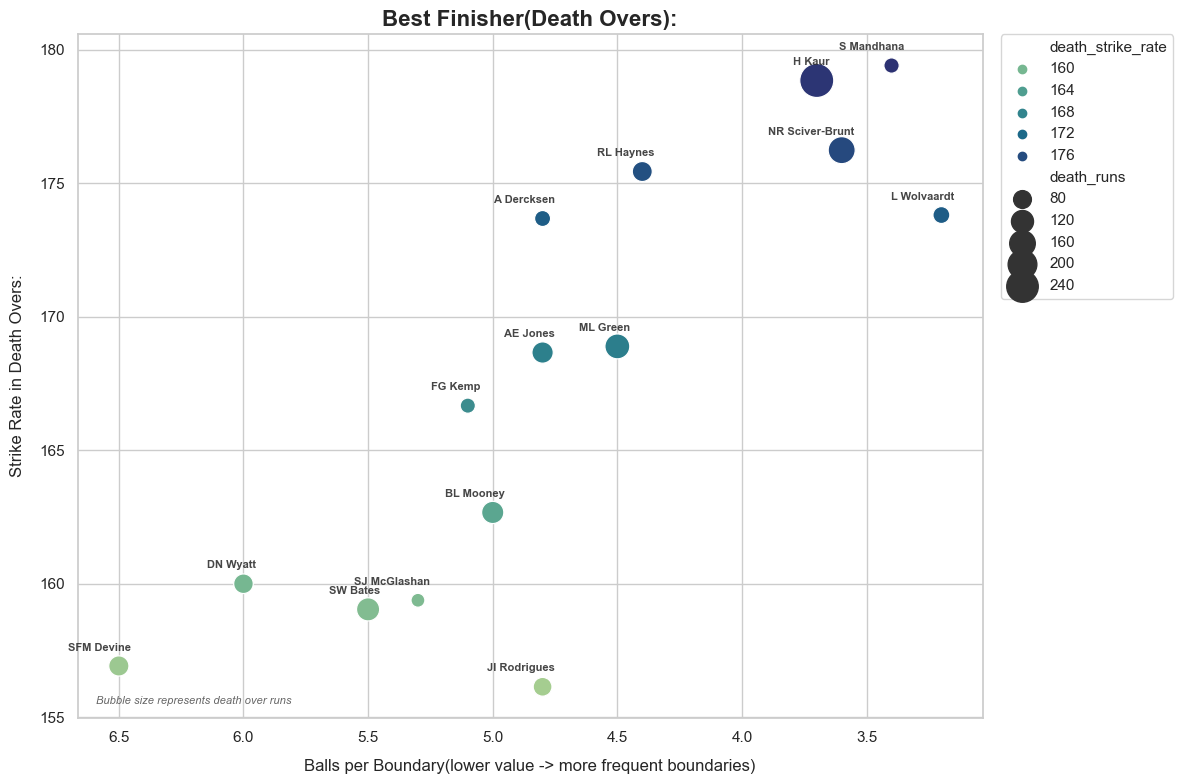

In [46]:
def finishers_plot(dataframe):
    sns.set_theme(style = 'whitegrid')
    fig, ax = plt.subplots(figsize = (12, 8))
    
    df_plot = dataframe.head(15).copy()
    
    sns.scatterplot(
        data = df_plot, 
        x = 'balls_per_boundary',
        y = 'death_strike_rate',
        size = 'death_runs',
        sizes = (100, 600),
        hue = 'death_strike_rate',
        palette = 'crest',
        ax = ax, 
        legend = True
    )
    
    ax.legend(
        loc = 'upper left',
        bbox_to_anchor = (1.02, 1),
        borderaxespad = 0,
        frameon = True
    )
    
    ax.invert_xaxis()
    
    text = []
    
    for idx, row in df_plot.iterrows():
        if pd.isna(row['balls_per_boundary']):
            continue
        
        x_offset = 0.05
        y_offset = 0.5
        
        t = ax.text(
            x = row['balls_per_boundary'] - x_offset,
            y = row['death_strike_rate'] + y_offset,
            s = row['batter'],
            fontsize = 8,
            fontweight = 'semibold',
            alpha = 0.85,
            ha = 'right',
            va = 'bottom'
        )
        text.append(t)
    
    ax.set_title(
        "Best Finisher(Death Overs):",
        fontsize = 16,
        fontweight = 'bold'
    )
    
    ax.set_xlabel(
        "Balls per Boundary(lower value -> more frequent boundaries)",
        fontsize = 12,
        labelpad = 10
    )
    
    ax.set_ylabel(
        "Strike Rate in Death Overs:",
        fontsize = 12,
        labelpad = 10
    )
    
    ax.text(
        0.02,
        0.02,
        "Bubble size represents death over runs",
        transform = ax.transAxes,
        fontsize = 8,
        style = 'italic',
        alpha = 0.7
    )
    
    plt.tight_layout()
    return fig, ax

df_finishers = generate_death_specialist_batter(df_w)
fig, ax = finishers_plot(df_finishers)
plt.show()

In [37]:
def generate_death_bowling(dataframe, min_balls = 30):
    data_death_b = dataframe[(dataframe['over'] >= 15.0) & (dataframe['over'] <= 20)].copy()
    
    data_death_b['balls_bowled'] = (data_death_b['wides'].fillna(0) == 0).astype(int)
    
    no_balls_conceded = data_death_b['noballs'].fillna(0) if 'noballs' in data_death_b.columns else 0
    data_death_b['runs_conceded'] = data_death_b['batter_runs'].fillna(0) + data_death_b['wides'].fillna(0) + no_balls_conceded
    
    data_death_b['is_boundary_conceded'] = data_death_b['batter_runs'].isin([4, 6]).astype(int)
    
    if 'dismissal_kind' in data_death_b.columns:
        data_death_b['is_bowler_wicket'] = (~data_death_b['dismissal_kind'].isin([
            'run out',
            'retired hurt'
        ]) & data_death_b['dismissal_kind'].notna()).astype(int)
    else:
        data_death_b['is_bowler_wicket'] = data_death_b['player_dismissed'].notna().astype(int) if 'player_dismissed' in data_death_b.columns else 0
        
    death_bowler_stats = data_death_b.groupby('bowler').agg(
        death_runs_conceded = ('runs_conceded', 'sum'),
        death_balls_bowled = ('balls_bowled', 'sum'),
        death_boundaries_conceded = ('is_boundary_conceded', 'sum'),
        death_wickets = ('is_bowler_wicket', 'sum'),
        matches_played = ('match_id', 'nunique')
    ).reset_index()
    
    best_death_bowlers = death_bowler_stats[death_bowler_stats['death_balls_bowled'] >= min_balls].copy()
    
    best_death_bowlers['death_economy_rate'] = ((best_death_bowlers['death_runs_conceded'] / best_death_bowlers['death_balls_bowled']) * 6).round(2)
    
    best_death_bowlers['balls_per_boundary_conceded'] = np.where(
        best_death_bowlers['death_boundaries_conceded'] > 0,
        (best_death_bowlers['death_balls_bowled'] / best_death_bowlers['death_boundaries_conceded']).round(1),
        best_death_bowlers['death_balls_bowled'].round(1)
    )
    
    death_bowler_leaderboard = best_death_bowlers.sort_values(
        by = 'death_economy_rate',
        ascending = True
    ).reset_index(drop = True)
    
    death_bowler_leaderboard.index = death_bowler_leaderboard.index + 1
    return death_bowler_leaderboard
    

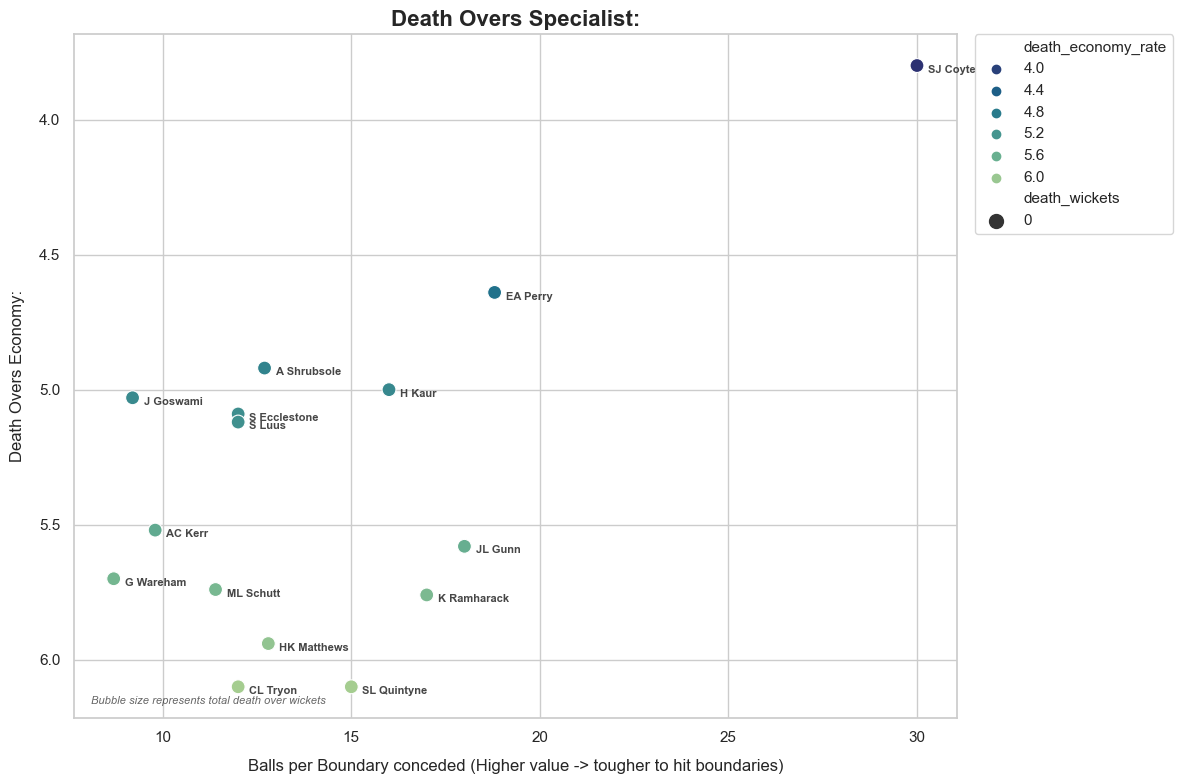

In [45]:
def death_bowlers_plot(dataframe):
    sns.set_theme(style = 'whitegrid')
    fig, ax = plt.subplots(figsize = (12, 8))
    
    df_plot_b = dataframe.head(15).copy()
    
    sns.scatterplot(
        data = df_plot_b,
        x = 'balls_per_boundary_conceded',
        y = 'death_economy_rate',
        size = 'death_wickets',
        sizes = (100, 600),
        hue = 'death_economy_rate',
        palette = 'crest_r',
        ax = ax,
        legend = True
    )
    
    ax.legend(
        loc = 'upper left',
        bbox_to_anchor = (1.02, 1),
        borderaxespad = 0,
        frameon = True
    )
    
    ax.invert_yaxis()
    
    for idx, row in df_plot_b.iterrows():
        if pd.isna(row['balls_per_boundary_conceded']):
            continue
        
        ax.annotate(
            row['bowler'],
            xy = (row['balls_per_boundary_conceded'], row['death_economy_rate']),
            xytext = (8, -3),
            textcoords = "offset points",
            fontsize = 8,
            fontweight = 'semibold',
            alpha = 0.85,
            ha = 'left',
            va = 'center'
        )
        
    ax.set_title(
        "Death Overs Specialist:",
        fontsize = 16,
        fontweight = 'bold'
    )
    
    ax.set_xlabel(
        "Balls per Boundary conceded (Higher value -> tougher to hit boundaries)",
        fontsize = 12, 
        labelpad = 10
    )
    
    ax.set_ylabel(
        "Death Overs Economy:",
        fontsize = 12, 
        labelpad = 10
    )
    
    ax.text(
        0.02,
        0.02,
        "Bubble size represents total death over wickets",
        transform = ax.transAxes,
        fontsize = 8,
        style = 'italic',
        alpha = 0.7
    )
    
    plt.tight_layout()
    return fig, ax

df_death_bowlers = generate_death_bowling(df_w)
fig, ax = death_bowlers_plot(df_death_bowlers)
plt.show()
